In [ ]:
!pip install -q segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.6 MB/s eta 0:00:00


In [ ]:
!nvidia-smi

Wed Sep 23 05:35:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Clone straight into Colab — faster than uploading from your laptop
!git clone https://github.com/yaufan/Knee_Segmentation_Database.git /content/cgmh

# Quick sanity check on the folder structure before we rely on it
!ls /content/cgmh/Data

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into '/content/cgmh'...
remote: Enumerating objects: 820, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 820 (delta 2), reused 0 (delta 0), pack-reused 814 (from 1)
Receiving objects: 100% (820/820), 586.51 MiB | 33.42 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Updating files: 100% (803/803), done.
Image  Label


In [ ]:
import os, glob
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss
import albumentations as A
from albumentations.pytorch import ToTensorV2

DATA_DIR = "/content/cgmh/Data"
IMAGE_DIR = os.path.join(DATA_DIR, "Image")
LABEL_DIR = os.path.join(DATA_DIR, "Label")
CHECKPOINT_DIR = "/content/drive/MyDrive/Knee_OA_Project/checkpoints"
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 40
LR = 1e-4
VAL_SPLIT = 0.2
SEED = 42

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class CGMHDataset(Dataset):
    def __init__(self, image_paths, label_paths, transform=None):
        self.image_paths, self.label_paths, self.transform = image_paths, label_paths, transform
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.image_paths[idx], cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
        mask = (cv2.imread(self.label_paths[idx], cv2.IMREAD_GRAYSCALE) > 127).astype(np.float32)
        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]
        if mask.dim() == 2:
            mask = mask.unsqueeze(0)
        return img, mask

MEAN, STD = (0.485,0.456,0.406), (0.229,0.224,0.225)
train_tf = A.Compose([A.Resize(IMG_SIZE,IMG_SIZE), A.HorizontalFlip(p=0.5), A.Rotate(limit=10,p=0.5),
                       A.RandomBrightnessContrast(p=0.3), A.Normalize(MEAN,STD), ToTensorV2()])
val_tf = A.Compose([A.Resize(IMG_SIZE,IMG_SIZE), A.Normalize(MEAN,STD), ToTensorV2()])

image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*")))
label_paths = sorted(glob.glob(os.path.join(LABEL_DIR, "*")))
assert len(image_paths) == len(label_paths) and len(image_paths) > 0, "Check IMAGE_DIR/LABEL_DIR paths above"

rng = np.random.default_rng(SEED)
idx = rng.permutation(len(image_paths))
n_val = int(len(idx) * VAL_SPLIT)
val_idx, train_idx = idx[:n_val], idx[n_val:]

train_ds = CGMHDataset([image_paths[i] for i in train_idx], [label_paths[i] for i in train_idx], train_tf)
val_ds = CGMHDataset([image_paths[i] for i in val_idx], [label_paths[i] for i in val_idx], val_tf)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

model = smp.UnetPlusPlus(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1).to(device)
loss_fn = DiceLoss(mode="binary")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

def dice_score(pred, target, eps=1e-7):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum()
    return (2*inter + eps) / (pred.sum() + target.sum() + eps)

best_val_dice = 0.0
for epoch in range(1, EPOCHS+1):
    model.train(); train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            loss = loss_fn(model(imgs), masks)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        train_loss += loss.item() * imgs.size(0)
    train_loss /= len(train_ds)

    model.eval(); val_dice_total = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                preds = model(imgs)
            val_dice_total += dice_score(preds, masks).item() * imgs.size(0)
    val_dice = val_dice_total / len(val_ds)

    print(f"Epoch {epoch}/{EPOCHS} | train loss: {train_loss:.4f} | val Dice: {val_dice:.4f}")
    torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "unetpp_last.pt"))
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "unetpp_best.pt"))
        print("  -> new best, saved")

print(f"Done. Best val Dice: {best_val_dice:.4f}")

Using device: cuda
Train: 320 | Val: 80


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

/tmp/ipykernel_1599/2160388255.py:63: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipykernel_1599/2160388255.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_1599/2160388255.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 1/40 | train loss: 0.6461 | val Dice: 0.8233
  -> new best, saved
Epoch 2/40 | train loss: 0.5483 | val Dice: 0.9024
  -> new best, saved
Epoch 3/40 | train loss: 0.4792 | val Dice: 0.9234
  -> new best, saved
Epoch 4/40 | train loss: 0.4097 | val Dice: 0.9456
  -> new best, saved
Epoch 5/40 | train loss: 0.3463 | val Dice: 0.9469
  -> new best, saved
Epoch 6/40 | train loss: 0.2896 | val Dice: 0.9621
  -> new best, saved
Epoch 7/40 | train loss: 0.2419 | val Dice: 0.9564
Epoch 8/40 | train loss: 0.2018 | val Dice: 0.9624
  -> new best, saved
Epoch 9/40 | train loss: 0.1699 | val Dice: 0.9676
  -> new best, saved
Epoch 10/40 | train loss: 0.1463 | val Dice: 0.9677
  -> new best, saved
Epoch 11/40 | train loss: 0.1272 | val Dice: 0.9698
  -> new best, saved
Epoch 12/40 | train loss: 0.1117 | val Dice: 0.9689
Epoch 13/40 | train loss: 0.1038 | val Dice: 0.9680
Epoch 14/40 | train loss: 0.0939 | val Dice: 0.9705
  -> new best, saved
Epoch 15/40 | train loss: 0.0842 | val Dice: 0.969

In [ ]:
import random

DATASET_ROOT = "/content/drive/MyDrive/knee oa project/dataset/test"
random.seed(42)

sample_paths = []
for grade in ["0", "1", "2", "3", "4"]:
    grade_dir = os.path.join(DATASET_ROOT, grade)
    imgs = glob.glob(os.path.join(grade_dir, "*"))
    sample_paths.extend(random.sample(imgs, min(3, len(imgs))))

print(f"Checking {len(sample_paths)} OAI images across grades 0-4")

Checking 15 OAI images across grades 0-4


Checking 15 OAI images across grades 0-4


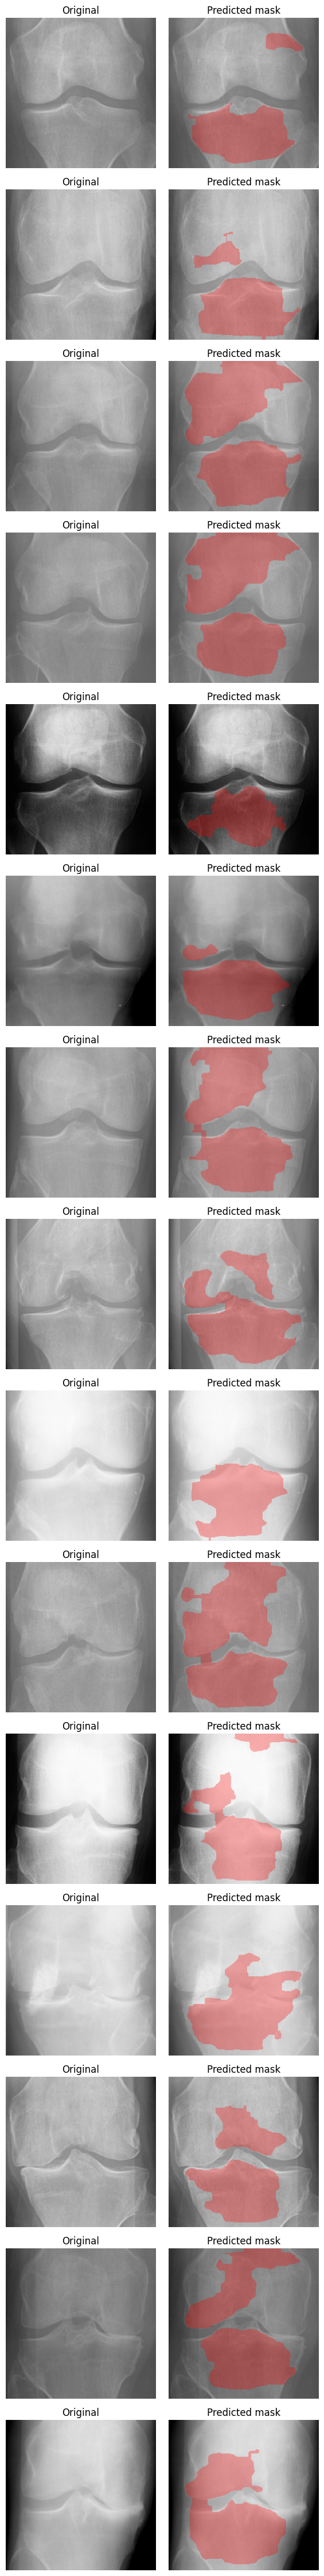

In [ ]:
import glob, os, random
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from scipy.ndimage import binary_fill_holes

CHECKPOINT_PATH = "/content/drive/MyDrive/Knee_OA_Project/checkpoints/unetpp_best.pt"
DATASET_ROOT = "/content/drive/MyDrive/knee oa project/dataset/test"
IMG_SIZE = 256

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.UnetPlusPlus(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=1)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.to(device).eval()

MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])

def clean_mask(mask, keep_top_n=2, min_area_ratio=0.01):
    kernel = np.ones((9, 9), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels > 1:
        areas = stats[1:, cv2.CC_STAT_AREA]
        total_area = mask.shape[0] * mask.shape[1]
        order = np.argsort(areas)[::-1][:keep_top_n]
        keep_labels = [i + 1 for i in order if areas[i] > min_area_ratio * total_area]
        mask = np.isin(labels, keep_labels).astype(np.uint8)
    mask = binary_fill_holes(mask).astype(np.uint8)
    return mask

def predict_mask(img_path):
    img = cv2.cvtColor(cv2.imread(img_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    norm = (resized / 255.0 - MEAN) / STD
    tensor = torch.tensor(norm.transpose(2, 0, 1), dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(tensor)).squeeze().cpu().numpy()
    prob_smoothed = cv2.GaussianBlur(prob, (9, 9), 0)   # smooths the source, not the result
    mask = (prob_smoothed > 0.5).astype(np.uint8)
    mask_resized = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
    mask_resized = clean_mask(mask_resized)
    return img, mask_resized

random.seed(42)
sample_paths = []
for grade in ["0", "1", "2", "3", "4"]:
    grade_dir = os.path.join(DATASET_ROOT, grade)
    imgs = glob.glob(os.path.join(grade_dir, "*"))
    sample_paths.extend(random.sample(imgs, min(3, len(imgs))))

print(f"Checking {len(sample_paths)} OAI images across grades 0-4")

fig, axes = plt.subplots(len(sample_paths), 2, figsize=(6, 3 * len(sample_paths)))
for i, path in enumerate(sample_paths):
    orig, mask = predict_mask(path)
    overlay = orig.copy()
    overlay[mask == 1] = [255, 0, 0]
    blended = cv2.addWeighted(orig, 0.7, overlay, 0.3, 0)
    axes[i, 0].imshow(orig); axes[i, 0].set_title("Original"); axes[i, 0].axis("off")
    axes[i, 1].imshow(blended); axes[i, 1].set_title("Predicted mask"); axes[i, 1].axis("off")
plt.tight_layout()
plt.savefig("/content/oai_sanity_check.png", dpi=100)
plt.show()

Saving WhatsApp Image 2026-09-23 at 12.29.42.jpeg to WhatsApp Image 2026-09-23 at 12.29.42.jpeg


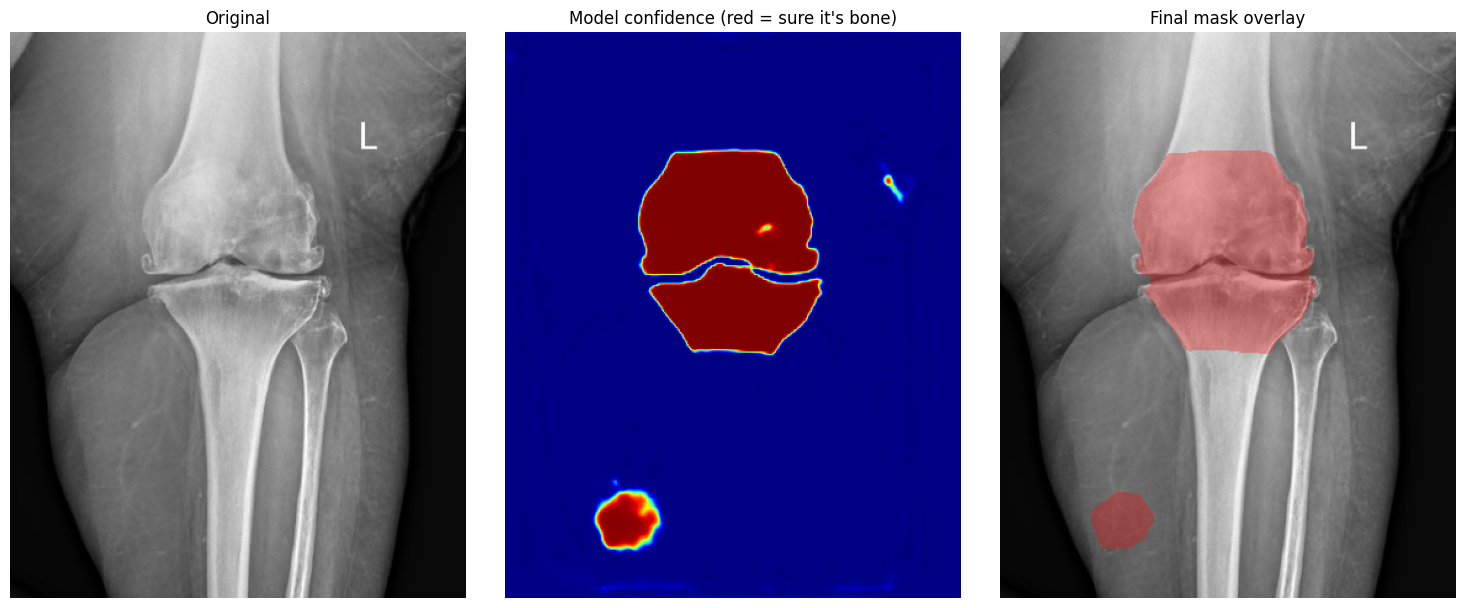

Mask covers 12.6% of the image


In [ ]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from scipy.ndimage import binary_fill_holes
from google.colab import files

# Switch to "unetpp_crop_best.pt" to test the retrained model once you have it
CHECKPOINT_PATH = "/content/drive/MyDrive/Knee_OA_Project/checkpoints/unetpp_best.pt"
IMG_SIZE = 256

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.UnetPlusPlus(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=1)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.to(device).eval()

MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])

def clean_mask(mask, keep_top_n=2, min_area_ratio=0.01):
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels > 1:
        areas = stats[1:, cv2.CC_STAT_AREA]
        total = mask.shape[0] * mask.shape[1]
        order = np.argsort(areas)[::-1][:keep_top_n]
        keep = [i + 1 for i in order if areas[i] > min_area_ratio * total]
        mask = np.isin(labels, keep).astype(np.uint8)
    return binary_fill_holes(mask).astype(np.uint8)

# Upload your X-ray from your laptop
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path, cv2.IMREAD_COLOR)
assert img is not None, "Could not read the image. Use a PNG or JPG file."
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Same preprocessing as training: resize to 256x256 and normalize
resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
norm = (resized / 255.0 - MEAN) / STD
tensor = torch.tensor(norm.transpose(2, 0, 1), dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    prob = torch.sigmoid(model(tensor)).squeeze().cpu().numpy()

# Scale back up to the original image size
prob_full = cv2.resize(prob, (img.shape[1], img.shape[0]))
mask = clean_mask((prob_full > 0.5).astype(np.uint8))

overlay = img.copy()
overlay[mask == 1] = [255, 0, 0]
blended = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes[0].imshow(img); axes[0].set_title("Original")
axes[1].imshow(prob_full, cmap="jet", vmin=0, vmax=1); axes[1].set_title("Model confidence (red = sure it's bone)")
axes[2].imshow(blended); axes[2].set_title("Final mask overlay")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Mask covers {mask.mean() * 100:.1f}% of the image")

In [ ]:
#unett training
import os, glob
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss
import albumentations as A
from albumentations.pytorch import ToTensorV2

DATA_DIR = "/content/cgmh/Data"
IMAGE_DIR = os.path.join(DATA_DIR, "Image")
LABEL_DIR = os.path.join(DATA_DIR, "Label")
CHECKPOINT_DIR = "/content/drive/MyDrive/Knee_OA_Project/checkpoints"
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 40
LR = 1e-4
VAL_SPLIT = 0.2
SEED = 42   # same seed = same train/val split as the U-Net++ run

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class CGMHDataset(Dataset):
    def __init__(self, image_paths, label_paths, transform=None):
        self.image_paths, self.label_paths, self.transform = image_paths, label_paths, transform
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.image_paths[idx], cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
        mask = (cv2.imread(self.label_paths[idx], cv2.IMREAD_GRAYSCALE) > 127).astype(np.float32)
        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]
        if mask.dim() == 2:
            mask = mask.unsqueeze(0)
        return img, mask

MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
train_tf = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.HorizontalFlip(p=0.5), A.Rotate(limit=10, p=0.5),
                      A.RandomBrightnessContrast(p=0.3), A.Normalize(MEAN, STD), ToTensorV2()])
val_tf = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.Normalize(MEAN, STD), ToTensorV2()])

image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*")))
label_paths = sorted(glob.glob(os.path.join(LABEL_DIR, "*")))
assert len(image_paths) == len(label_paths) and len(image_paths) > 0, "Check IMAGE_DIR/LABEL_DIR paths"

rng = np.random.default_rng(SEED)
idx = rng.permutation(len(image_paths))
n_val = int(len(idx) * VAL_SPLIT)
val_idx, train_idx = idx[:n_val], idx[n_val:]

train_ds = CGMHDataset([image_paths[i] for i in train_idx], [label_paths[i] for i in train_idx], train_tf)
val_ds = CGMHDataset([image_paths[i] for i in val_idx], [label_paths[i] for i in val_idx], val_tf)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

# The only real change: plain U-Net instead of U-Net++
model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1).to(device)

loss_fn = DiceLoss(mode="binary")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

def dice_score(pred, target, eps=1e-7):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum()
    return (2 * inter + eps) / (pred.sum() + target.sum() + eps)

best_val_dice = 0.0
for epoch in range(1, EPOCHS + 1):
    model.train(); train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=use_amp):
            loss = loss_fn(model(imgs), masks)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        train_loss += loss.item() * imgs.size(0)
    train_loss /= len(train_ds)

    model.eval(); val_dice_total = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            with torch.amp.autocast("cuda", enabled=use_amp):
                preds = model(imgs)
            val_dice_total += dice_score(preds, masks).item() * imgs.size(0)
    val_dice = val_dice_total / len(val_ds)

    print(f"Epoch {epoch}/{EPOCHS} | train loss: {train_loss:.4f} | val Dice: {val_dice:.4f}")
    torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "unet_last.pt"))
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "unet_best.pt"))
        print("  -> new best, saved")

print(f"Done. Best val Dice: {best_val_dice:.4f}")

Using device: cuda
Train: 320 | Val: 80


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch 1/40 | train loss: 0.6250 | val Dice: 0.8017
  -> new best, saved
Epoch 2/40 | train loss: 0.4895 | val Dice: 0.8923
  -> new best, saved
Epoch 3/40 | train loss: 0.4118 | val Dice: 0.9299
  -> new best, saved
Epoch 4/40 | train loss: 0.3506 | val Dice: 0.9331
  -> new best, saved
Epoch 5/40 | train loss: 0.2983 | val Dice: 0.9390
  -> new best, saved
Epoch 6/40 | train loss: 0.2562 | val Dice: 0.9366
Epoch 7/40 | train loss: 0.2211 | val Dice: 0.9386
Epoch 8/40 | train loss: 0.1928 | val Dice: 0.9442
  -> new best, saved
Epoch 9/40 | train loss: 0.1707 | val Dice: 0.9469
  -> new best, saved
Epoch 10/40 | train loss: 0.1521 | val Dice: 0.9463
Epoch 11/40 | train loss: 0.1371 | val Dice: 0.9613
  -> new best, saved
Epoch 12/40 | train loss: 0.1193 | val Dice: 0.9611
Epoch 13/40 | train loss: 0.1064 | val Dice: 0.9683
  -> new best, saved
Epoch 14/40 | train loss: 0.0953 | val Dice: 0.9693
  -> new best, saved
Epoch 15/40 | train loss: 0.0877 | val Dice: 0.9583
Epoch 16/40 | train

In [ ]:
import os, glob
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss
import albumentations as A
from albumentations.pytorch import ToTensorV2

DATA_DIR = "/content/cgmh/Data"
IMAGE_DIR = os.path.join(DATA_DIR, "Image")
LABEL_DIR = os.path.join(DATA_DIR, "Label")
CHECKPOINT_DIR = "/content/drive/MyDrive/Knee_OA_Project/checkpoints"
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 20
LR = 1e-4
VAL_SPLIT = 0.2
SEED = 42

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class CGMHDataset(Dataset):
    def __init__(self, image_paths, label_paths, transform=None):
        self.image_paths, self.label_paths, self.transform = image_paths, label_paths, transform
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.image_paths[idx], cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
        mask = (cv2.imread(self.label_paths[idx], cv2.IMREAD_GRAYSCALE) > 127).astype(np.float32)
        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]
        if mask.dim() == 2:
            mask = mask.unsqueeze(0)
        return img, mask

MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
train_tf = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.HorizontalFlip(p=0.5), A.Rotate(limit=10, p=0.5),
                      A.RandomBrightnessContrast(p=0.3), A.Normalize(MEAN, STD), ToTensorV2()])
val_tf = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.Normalize(MEAN, STD), ToTensorV2()])

image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*")))
label_paths = sorted(glob.glob(os.path.join(LABEL_DIR, "*")))
assert len(image_paths) == len(label_paths) and len(image_paths) > 0, "Check IMAGE_DIR/LABEL_DIR paths"

rng = np.random.default_rng(SEED)
idx = rng.permutation(len(image_paths))
n_val = int(len(idx) * VAL_SPLIT)
val_idx, train_idx = idx[:n_val], idx[n_val:]

train_ds = CGMHDataset([image_paths[i] for i in train_idx], [label_paths[i] for i in train_idx], train_tf)
val_ds = CGMHDataset([image_paths[i] for i in val_idx], [label_paths[i] for i in val_idx], val_tf)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

model = smp.DeepLabV3Plus(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1).to(device)

loss_fn = DiceLoss(mode="binary")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

def dice_score(pred, target, eps=1e-7):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum()
    return (2 * inter + eps) / (pred.sum() + target.sum() + eps)

best_val_dice = 0.0
for epoch in range(1, EPOCHS + 1):
    model.train(); train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=use_amp):
            loss = loss_fn(model(imgs), masks)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        train_loss += loss.item() * imgs.size(0)
    train_loss /= len(train_ds)

    model.eval(); val_dice_total = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            with torch.amp.autocast("cuda", enabled=use_amp):
                preds = model(imgs)
            val_dice_total += dice_score(preds, masks).item() * imgs.size(0)
    val_dice = val_dice_total / len(val_ds)

    print(f"Epoch {epoch}/{EPOCHS} | train loss: {train_loss:.4f} | val Dice: {val_dice:.4f}")
    torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "deeplab_last.pt"))
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "deeplab_best.pt"))
        print("  -> new best, saved")

print(f"Done. DeepLabV3+ best val Dice: {best_val_dice:.4f}")

Using device: cuda
Train: 320 | Val: 80
Epoch 1/20 | train loss: 0.5689 | val Dice: 0.7839
  -> new best, saved
Epoch 2/20 | train loss: 0.3508 | val Dice: 0.8893
  -> new best, saved
Epoch 3/20 | train loss: 0.2539 | val Dice: 0.9211
  -> new best, saved
Epoch 4/20 | train loss: 0.2034 | val Dice: 0.9167
Epoch 5/20 | train loss: 0.1706 | val Dice: 0.9279
  -> new best, saved
Epoch 6/20 | train loss: 0.1454 | val Dice: 0.9297
  -> new best, saved
Epoch 7/20 | train loss: 0.1280 | val Dice: 0.9408
  -> new best, saved
Epoch 8/20 | train loss: 0.1126 | val Dice: 0.9312
Epoch 9/20 | train loss: 0.1040 | val Dice: 0.9312
Epoch 10/20 | train loss: 0.0966 | val Dice: 0.9473
  -> new best, saved
Epoch 11/20 | train loss: 0.0885 | val Dice: 0.9462
Epoch 12/20 | train loss: 0.0832 | val Dice: 0.9472
Epoch 13/20 | train loss: 0.0769 | val Dice: 0.9518
  -> new best, saved
Epoch 14/20 | train loss: 0.0697 | val Dice: 0.9541
  -> new best, saved
Epoch 15/20 | train loss: 0.0639 | val Dice: 0.9561


In [ ]:
import os, glob, time
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

DATA_DIR = "/content/cgmh/Data"
CHECKPOINT_DIR = "/content/drive/MyDrive/Knee_OA_Project/checkpoints"
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 20
SEED = 42

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

image_paths = sorted(glob.glob(os.path.join(DATA_DIR, "Image", "*")))
label_paths = sorted(glob.glob(os.path.join(DATA_DIR, "Label", "*")))
rng = np.random.default_rng(SEED)
idx = rng.permutation(len(image_paths))
n_val = int(len(idx) * 0.2)
val_idx, train_idx = idx[:n_val], idx[n_val:]

# Same augmentation as the other models (normalization happens inside Mask R-CNN)
train_aug = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.HorizontalFlip(p=0.5), A.Rotate(limit=10, p=0.5),
                       A.RandomBrightnessContrast(p=0.3)])
val_aug = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE)])

class CGMHInstanceDataset(Dataset):
    def __init__(self, img_paths, lbl_paths, aug):
        self.img_paths, self.lbl_paths, self.aug = img_paths, lbl_paths, aug
    def __len__(self): return len(self.img_paths)
    def __getitem__(self, i):
        img = cv2.cvtColor(cv2.imread(self.img_paths[i], cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
        mask = (cv2.imread(self.lbl_paths[i], cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
        out = self.aug(image=img, mask=mask)
        img, mask = out["image"], out["mask"]

        # Split the combined bone mask into separate objects (largest 2 regions)
        n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
        comps = [c for c in range(1, n) if stats[c, cv2.CC_STAT_AREA] > 50]
        comps = sorted(comps, key=lambda c: stats[c, cv2.CC_STAT_AREA], reverse=True)[:2]

        boxes, masks = [], []
        for c in comps:
            x, y, w, h = stats[c, :4]
            boxes.append([x, y, x + w, y + h])
            masks.append((labels == c).astype(np.uint8))

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4),
            "labels": torch.ones(len(boxes), dtype=torch.int64),   # class 1 = bone
            "masks": torch.tensor(np.array(masks), dtype=torch.uint8).reshape(-1, IMG_SIZE, IMG_SIZE),
        }
        img_t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        return img_t, target, torch.from_numpy(mask)

collate = lambda batch: tuple(zip(*batch))
train_loader = DataLoader(CGMHInstanceDataset([image_paths[i] for i in train_idx], [label_paths[i] for i in train_idx], train_aug),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=collate)
val_loader = DataLoader(CGMHInstanceDataset([image_paths[i] for i in val_idx], [label_paths[i] for i in val_idx], val_aug),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate)
print(f"Train: {len(train_idx)} | Val: {len(val_idx)}")

model = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT, min_size=IMG_SIZE, max_size=IMG_SIZE)
model.roi_heads.box_predictor = FastRCNNPredictor(model.roi_heads.box_predictor.cls_score.in_features, 2)
model.roi_heads.mask_predictor = MaskRCNNPredictor(model.roi_heads.mask_predictor.conv5_mask.in_channels, 256, 2)
model.to(device)

optimizer = torch.optim.SGD([p for p in model.parameters() if p.requires_grad], lr=0.005, momentum=0.9, weight_decay=5e-4)
use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

best_val_dice = 0.0
for epoch in range(1, EPOCHS + 1):
    start = time.time()
    model.train(); train_loss = 0.0
    for imgs, targets, _ in train_loader:
        imgs = [im.to(device) for im in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=use_amp):
            loss = sum(model(imgs, targets).values())
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation: merge predicted bone masks into one and compare with the true mask (Dice)
    model.eval(); dices = []
    with torch.no_grad():
        for imgs, _, gt_masks in val_loader:
            outputs = model([im.to(device) for im in imgs])
            for out, gt in zip(outputs, gt_masks):
                keep = out["scores"] > 0.5
                if keep.any():
                    pred = (out["masks"][keep, 0] > 0.5).any(dim=0).float().cpu()
                else:
                    pred = torch.zeros(gt.shape, dtype=torch.float32)
                gt = gt.float()
                dices.append(((2 * (pred * gt).sum() + 1e-7) / (pred.sum() + gt.sum() + 1e-7)).item())
    val_dice = float(np.mean(dices))

    print(f"Epoch {epoch}/{EPOCHS} | train loss: {train_loss:.4f} | val Dice: {val_dice:.4f} | epoch time: {time.time() - start:.0f}s")
    torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "maskrcnn_last.pt"))
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "maskrcnn_best.pt"))
        print("  -> new best, saved")

print(f"Done. Mask R-CNN best val Dice: {best_val_dice:.4f}")

Using device: cuda
Train: 320 | Val: 80
Epoch 1/20 | train loss: 0.7588 | val Dice: 0.9258 | epoch time: 44s
  -> new best, saved
Epoch 2/20 | train loss: 0.3589 | val Dice: 0.9490 | epoch time: 30s
  -> new best, saved
Epoch 3/20 | train loss: 0.3269 | val Dice: 0.9503 | epoch time: 30s
  -> new best, saved
Epoch 4/20 | train loss: 0.3117 | val Dice: 0.9537 | epoch time: 31s
  -> new best, saved
Epoch 5/20 | train loss: 0.2988 | val Dice: 0.9560 | epoch time: 30s
  -> new best, saved
Epoch 6/20 | train loss: 0.2935 | val Dice: 0.9442 | epoch time: 28s
Epoch 7/20 | train loss: 0.2775 | val Dice: 0.9556 | epoch time: 26s
Epoch 8/20 | train loss: 0.2755 | val Dice: 0.9557 | epoch time: 29s
Epoch 9/20 | train loss: 0.2713 | val Dice: 0.9482 | epoch time: 30s
Epoch 10/20 | train loss: 0.2655 | val Dice: 0.9550 | epoch time: 31s
Epoch 11/20 | train loss: 0.2441 | val Dice: 0.9576 | epoch time: 31s
  -> new best, saved
Epoch 12/20 | train loss: 0.2260 | val Dice: 0.9566 | epoch time: 30s
Epo

Evaluating on 80 validation images
Done: Vanilla U-Net
Done: U-Net++
Done: DeepLabV3+
Done: Mask R-CNN

=== Segmentation metrics on 80 CGMH validation images (pixel level) ===
               Precision  Recall  F1 (Dice)     IoU  Pixel Accuracy
Model                                                              
Vanilla U-Net     0.9727  0.9728     0.9727  0.9469          0.9943
U-Net++           0.9756  0.9720     0.9738  0.9490          0.9946
DeepLabV3+        0.9743  0.9500     0.9620  0.9268          0.9922
Mask R-CNN        0.9571  0.9644     0.9607  0.9244          0.9918


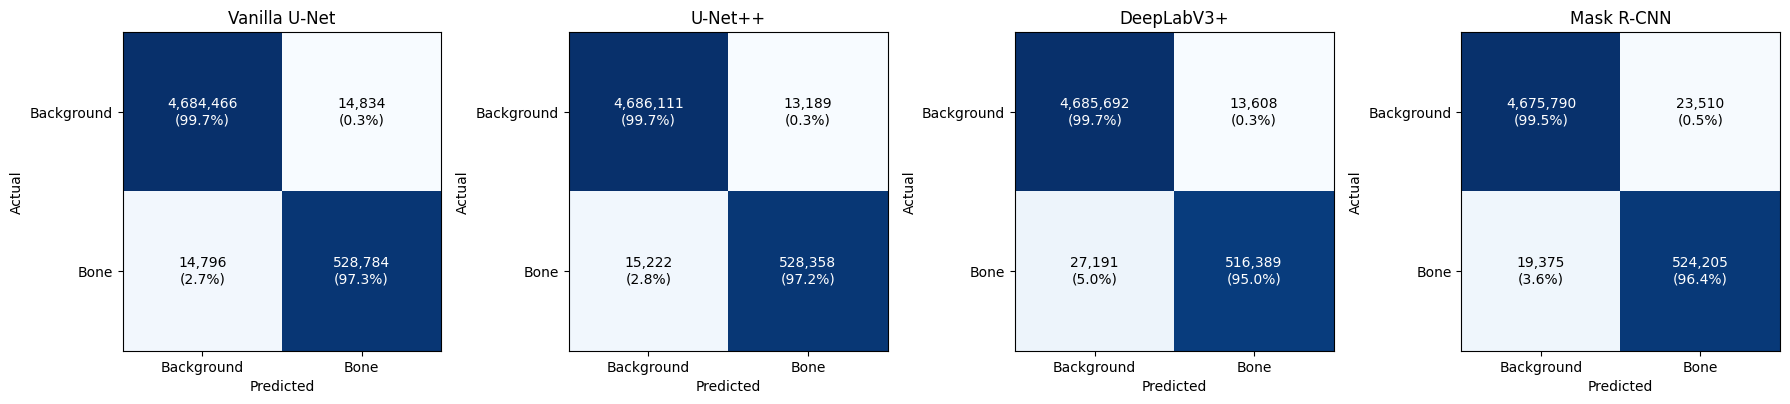


Saved table and confusion matrix image to /content/drive/MyDrive/Knee_OA_Project/results


In [ ]:
import os, glob
import numpy as np
import cv2
import torch
import pandas as pd
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

DATA_DIR = "/content/cgmh/Data"
CKPT_DIR = "/content/drive/MyDrive/Knee_OA_Project/checkpoints"
OUT_DIR = "/content/drive/MyDrive/Knee_OA_Project/results"
IMG_SIZE = 256
SEED = 42
os.makedirs(OUT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Same validation split as training (seed 42 -> the same 80 images)
image_paths = sorted(glob.glob(os.path.join(DATA_DIR, "Image", "*")))
label_paths = sorted(glob.glob(os.path.join(DATA_DIR, "Label", "*")))
rng = np.random.default_rng(SEED)
idx = rng.permutation(len(image_paths))
val_idx = idx[:int(len(idx) * 0.2)]
val_pairs = [(image_paths[i], label_paths[i]) for i in val_idx]
print(f"Evaluating on {len(val_pairs)} validation images")

MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])

def load_pair(img_path, lbl_path):
    img = cv2.resize(cv2.cvtColor(cv2.imread(img_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB), (IMG_SIZE, IMG_SIZE))
    gt = (cv2.imread(lbl_path, cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
    gt = cv2.resize(gt, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    return img, gt

def predict_smp(model, img):
    norm = (img / 255.0 - MEAN) / STD
    t = torch.tensor(norm.transpose(2, 0, 1), dtype=torch.float32).unsqueeze(0).to(device)
    return (torch.sigmoid(model(t)).squeeze().cpu().numpy() > 0.5).astype(np.uint8)

def predict_maskrcnn(model, img):
    t = torch.from_numpy(img).permute(2, 0, 1).float().div(255.0).to(device)
    out = model([t])[0]
    keep = out["scores"] > 0.5
    if not keep.any():
        return np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    return (out["masks"][keep, 0] > 0.5).any(dim=0).cpu().numpy().astype(np.uint8)

def build_maskrcnn():
    m = maskrcnn_resnet50_fpn(weights=None, weights_backbone=None, min_size=IMG_SIZE, max_size=IMG_SIZE)
    m.roi_heads.box_predictor = FastRCNNPredictor(m.roi_heads.box_predictor.cls_score.in_features, 2)
    m.roi_heads.mask_predictor = MaskRCNNPredictor(m.roi_heads.mask_predictor.conv5_mask.in_channels, 256, 2)
    return m

MODELS = {
    "Vanilla U-Net": (lambda: smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=1), "unet_best.pt", predict_smp),
    "U-Net++":       (lambda: smp.UnetPlusPlus(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=1), "unetpp_best.pt", predict_smp),
    "DeepLabV3+":    (lambda: smp.DeepLabV3Plus(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=1), "deeplab_best.pt", predict_smp),
    "Mask R-CNN":    (build_maskrcnn, "maskrcnn_best.pt", predict_maskrcnn),
}

rows, confusion = [], {}
for name, (builder, ckpt, predict_fn) in MODELS.items():
    ckpt_path = os.path.join(CKPT_DIR, ckpt)
    if not os.path.exists(ckpt_path):
        print(f"Skipping {name}: {ckpt} not found")
        continue
    model = builder()
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.to(device).eval()

    TP = FP = FN = TN = 0
    with torch.no_grad():
        for img_path, lbl_path in val_pairs:
            img, gt = load_pair(img_path, lbl_path)
            pred = predict_fn(model, img)
            TP += int(((pred == 1) & (gt == 1)).sum())
            FP += int(((pred == 1) & (gt == 0)).sum())
            FN += int(((pred == 0) & (gt == 1)).sum())
            TN += int(((pred == 0) & (gt == 0)).sum())

    precision = TP / (TP + FP) if (TP + FP) else 0.0
    recall = TP / (TP + FN) if (TP + FN) else 0.0
    f1 = 2 * TP / (2 * TP + FP + FN) if (TP + FP + FN) else 0.0
    iou = TP / (TP + FP + FN) if (TP + FP + FN) else 0.0
    accuracy = (TP + TN) / (TP + FP + FN + TN)

    rows.append({"Model": name, "Precision": precision, "Recall": recall,
                 "F1 (Dice)": f1, "IoU": iou, "Pixel Accuracy": accuracy})
    confusion[name] = np.array([[TN, FP], [FN, TP]])
    print(f"Done: {name}")
    del model
    torch.cuda.empty_cache()

results = pd.DataFrame(rows).set_index("Model").round(4)
print("\n=== Segmentation metrics on 80 CGMH validation images (pixel level) ===")
print(results.to_string())
results.to_csv(os.path.join(OUT_DIR, "segmentation_metrics.csv"))

# Confusion matrices: rows = actual, columns = predicted
n = len(confusion)
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.5))
axes = np.atleast_1d(axes)
labels = ["Background", "Bone"]
for ax, (name, cm) in zip(axes, confusion.items()):
    pct = cm / cm.sum(axis=1, keepdims=True) * 100
    ax.imshow(pct, cmap="Blues", vmin=0, vmax=100)
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f"{cm[r, c]:,}\n({pct[r, c]:.1f}%)", ha="center", va="center",
                    color="white" if pct[r, c] > 50 else "black", fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(name)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrices.png"), dpi=150)
plt.show()

print(f"\nSaved table and confusion matrix image to {OUT_DIR}")